# Stage 3 Polybot Backtest Visualization

Loads the Kotlin `polybot-backtest` outputs, summarizes contract-level results,
and visualizes the best contract in a stage2-style workflow.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import json

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


## Configuration

In [2]:
BACKTEST_DIR = Path('../../data/polybot_backtest')

TRADES_DIR = Path('../../data/polygon_trades_processed')
SELECTED_WALLETS_PATH = Path('../../data/trade_signals_workspace_v2/selected_wallets_v2.parquet')

TOP_N_CONTRACTS = 10
AGGREGATE_RESAMPLE = '1h'
AGGREGATE_MAX_CONTRACTS = None  # Set int for faster iteration during exploration


## Load summaries

In [3]:
summaries_path = BACKTEST_DIR / 'summaries.json'
if not summaries_path.exists():
    raise FileNotFoundError(f'Missing summaries file: {summaries_path}')

summaries = pd.DataFrame(json.loads(summaries_path.read_text()))
if summaries.empty:
    raise ValueError('Backtest summaries are empty.')

summaries['firstTradeAt'] = pd.to_datetime(summaries['firstTradeAt'], utc=True)
summaries['lastTradeAt'] = pd.to_datetime(summaries['lastTradeAt'], utc=True)
summaries.sort_values('finalEstimatedPnl', ascending=False, key=abs).head(10)


,conditionId,eventCount,orderCount,fillCount,finalRealizedPnl,finalEstimatedPnl,totalImpliedPnl,finalPosition,finalBuyVolume,finalSellVolume,violationCount,firstTradeAt,lastTradeAt,endDateIso,lastConditionTradeTs,copyWalletPnl
4257,0x178b29c0bb3a1c482f37f42e2420a1aa686b960ef000...,9456,67,19,0.0,1180.545651,1547.806247,2166.71,704.49204936,0,0,2026-06-13 21:02:31+00:00,2026-07-01 22:15:40+00:00,2026-07-01T22:15:40Z,2026-07-01T22:15:40Z,4193.842456
24300,0x876047c0df88886ddbe468fe811bc75a667da45a552d...,12181,10,12,0.0,-752.629720,269.676991,1358.81,797.1455088,0,0,2026-06-02 19:09:50+00:00,2026-06-16 00:32:48+00:00,2026-06-16T00:32:48Z,2026-06-16T00:32:48Z,-329.217043
30648,0xab1209b73e1ce9ebb4905dad781496385b5102c04888...,13274,70,89,0.0,741.877995,2352.870182,2777.22,776.024648240000006685,0,0,2026-06-11 20:34:22+00:00,2026-06-15 02:06:21+00:00,2026-06-15T02:06:21Z,2026-06-15T02:06:21Z,4089.320019
19428,0x6bf0cbc0938ea215ef8660f2aa37475ae8b82950edc5...,4154,19,94,0.0,-567.520494,-792.306600,8932.86,762.39800861000000005088,0,0,2026-06-16 16:53:22+00:00,2026-06-18 00:33:32+00:00,2026-06-18T00:33:32Z,2026-06-18T00:33:32Z,-718.293983
7966,0x2bef40a1f62d045527228e699990d1bd1f97906b2458...,17880,57,14,0.0,481.996761,298.603726,928.01,633.39100125000000000,0,0,2026-04-28 20:07:24+00:00,2026-06-01 06:28:52+00:00,2026-06-01T06:28:52Z,2026-06-01T06:28:52Z,1365.656831
12783,0x46dd571d8c32bd58dcc553ae6c2a1ae8dda6d1ec6994...,6168,4,25,0.0,365.694888,694.498078,1375.87,684.61476695000000612,0,0,2026-06-15 23:10:45+00:00,2026-06-20 02:03:28+00:00,2026-06-20T02:03:28Z,2026-06-20T02:03:28Z,2814.764336
15170,0x543fcf4637bc0e8a59bcd85ed35fff7dd469925a9c12...,1555,14,21,0.0,349.891508,35.282010,557.03,532.38595846,0,0,2026-06-25 04:28:08+00:00,2026-06-27 08:20:13+00:00,2026-06-27T08:20:13Z,2026-06-27T13:31:37Z,37.728968
40425,0xe1e26f6d0c5f621011ae53140fd27c0ce3b965c8b3a6...,3996,32,23,0.0,-338.000074,-372.920000,3003.33,368.033374,0,0,2026-06-23 03:02:14+00:00,2026-07-01 21:24:05+00:00,2026-07-01T21:24:05Z,2026-07-01T21:24:05Z,-1222.704515
29468,0xa48ee32a0cbe5bc1a48844bd14e1691701d3bf8f45f4...,19454,21,21,0.0,-322.846782,34.182817,967.62,363.26539806999985601,0,0,2026-05-25 15:51:34+00:00,2026-06-15 00:22:24+00:00,2026-06-15T00:22:24Z,2026-06-15T00:22:24Z,504.303209
16161,0x59a37ea3830d532957b04d3c437a329e14a5dc840096...,14366,119,70,0.0,-315.223860,178.837650,1446.86,783.918113490000000018144,0,0,2026-05-01 14:35:04+00:00,2026-06-02 00:26:18+00:00,2026-06-02T00:26:18Z,2026-06-02T00:26:18Z,-198.971185


In [4]:
totals = {
    'contracts_total': len(summaries),
    'contracts_with_fills': (summaries['fillCount'] > 0).sum(),
    'contracts_with_orders': (summaries['orderCount'] > 0).sum(),
    'total_estimated_pnl': summaries['finalEstimatedPnl'].sum(),
    'mean_estimated_pnl': summaries['finalEstimatedPnl'].mean(),
    'median_estimated_pnl': summaries['finalEstimatedPnl'].median(),
    'min_estimated_pnl': summaries['finalEstimatedPnl'].min(),
    'max_estimated_pnl': summaries['finalEstimatedPnl'].max(),
    'positive_pnl_contracts': (summaries['finalEstimatedPnl'] > 0).sum(),
    'negative_pnl_contracts': (summaries['finalEstimatedPnl'] < 0).sum(),
    'zero_pnl_contracts': (summaries['finalEstimatedPnl'] == 0).sum(),
    'total_orders': int(summaries['orderCount'].sum()),
    'total_fills': int(summaries['fillCount'].sum()),
    'total_events': int(summaries['eventCount'].sum()),
}

pd.DataFrame([totals]).T.rename(columns={0: 'value'})


,value
contracts_total,4.589400e+04
contracts_with_fills,1.787000e+03
contracts_with_orders,3.891000e+03
total_estimated_pnl,6.866114e+03
mean_estimated_pnl,1.496081e-01
median_estimated_pnl,0.000000e+00
min_estimated_pnl,-7.526297e+02
max_estimated_pnl,1.180546e+03
positive_pnl_contracts,7.660000e+02
negative_pnl_contracts,8.240000e+02


## Per-contract stats

In [5]:
display_cols = ['conditionId', 'finalEstimatedPnl', 'finalRealizedPnl', 'orderCount', 'fillCount', 'copyWalletPnl', 'firstTradeAt', 'lastTradeAt']

stats_sorted = summaries.sort_values('finalEstimatedPnl', ascending=False, key=abs).reset_index(drop=True)

# top N
stats_sorted.head(TOP_N_CONTRACTS)[display_cols]


,conditionId,finalEstimatedPnl,finalRealizedPnl,orderCount,fillCount,copyWalletPnl,firstTradeAt,lastTradeAt
0,0x178b29c0bb3a1c482f37f42e2420a1aa686b960ef000...,1180.545651,0.0,67,19,4193.842456,2026-06-13 21:02:31+00:00,2026-07-01 22:15:40+00:00
1,0x876047c0df88886ddbe468fe811bc75a667da45a552d...,-752.629720,0.0,10,12,-329.217043,2026-06-02 19:09:50+00:00,2026-06-16 00:32:48+00:00
2,0xab1209b73e1ce9ebb4905dad781496385b5102c04888...,741.877995,0.0,70,89,4089.320019,2026-06-11 20:34:22+00:00,2026-06-15 02:06:21+00:00
3,0x6bf0cbc0938ea215ef8660f2aa37475ae8b82950edc5...,-567.520494,0.0,19,94,-718.293983,2026-06-16 16:53:22+00:00,2026-06-18 00:33:32+00:00
4,0x2bef40a1f62d045527228e699990d1bd1f97906b2458...,481.996761,0.0,57,14,1365.656831,2026-04-28 20:07:24+00:00,2026-06-01 06:28:52+00:00
5,0x46dd571d8c32bd58dcc553ae6c2a1ae8dda6d1ec6994...,365.694888,0.0,4,25,2814.764336,2026-06-15 23:10:45+00:00,2026-06-20 02:03:28+00:00
6,0x543fcf4637bc0e8a59bcd85ed35fff7dd469925a9c12...,349.891508,0.0,14,21,37.728968,2026-06-25 04:28:08+00:00,2026-06-27 08:20:13+00:00
7,0xe1e26f6d0c5f621011ae53140fd27c0ce3b965c8b3a6...,-338.000074,0.0,32,23,-1222.704515,2026-06-23 03:02:14+00:00,2026-07-01 21:24:05+00:00
8,0xa48ee32a0cbe5bc1a48844bd14e1691701d3bf8f45f4...,-322.846782,0.0,21,21,504.303209,2026-05-25 15:51:34+00:00,2026-06-15 00:22:24+00:00
9,0x59a37ea3830d532957b04d3c437a329e14a5dc840096...,-315.223860,0.0,119,70,-198.971185,2026-05-01 14:35:04+00:00,2026-06-02 00:26:18+00:00


## Per Day Stats

In [6]:
pd.to_datetime(summaries['endDateIso'])

0       2026-06-23 17:16:37+00:00
1       2026-06-01 15:41:06+00:00
2       2026-06-25 12:06:55+00:00
3       2026-07-12 03:05:02+00:00
4       2026-06-09 17:48:48+00:00
                   ...           
45889   2026-07-08 04:04:58+00:00
45890   2026-06-01 08:48:08+00:00
45891   2026-06-14 08:31:10+00:00
45892   2026-07-09 00:14:44+00:00
45893   2026-06-01 12:08:04+00:00
Name: endDateIso, Length: 45894, dtype: datetime64[ns, UTC]

In [7]:
summaries.groupby(pd.to_datetime(summaries['endDateIso']).dt.date).agg(
    contracts=('conditionId', 'count'),
    contracts_with_fills=('fillCount', lambda x: (x > 0).sum()),
    total_estimated_pnl=('finalEstimatedPnl', 'sum'),
    mean_estimated_pnl=('finalEstimatedPnl', 'mean'),
    median_estimated_pnl=('finalEstimatedPnl', 'median')).sort_values('total_estimated_pnl', ascending=False, key=abs).head(10)

,contracts,contracts_with_fills,total_estimated_pnl,mean_estimated_pnl,median_estimated_pnl
endDateIso,,,,,
2026-07-01,1346,56,1010.461227,0.750714,0.0
2026-06-01,1343,53,958.893712,0.713994,0.0
2026-06-18,1224,47,-686.983212,-0.561261,0.0
2026-06-27,770,33,585.902698,0.760913,0.0
2026-06-20,729,23,570.124620,0.782064,0.0
2026-06-09,1026,46,512.006015,0.499031,0.0
2026-06-11,914,42,335.406986,0.366966,0.0
2026-07-07,939,39,260.101886,0.276999,0.0
2026-06-04,929,45,255.546738,0.275077,0.0


## Aggregate PnL vs wallet cohort

In [8]:
selected_wallets_all = pd.read_parquet(SELECTED_WALLETS_PATH, columns=['wallet', 'wallet_group'])
if 'wallet_group' in selected_wallets_all.columns:
    watched_wallets = set(
        selected_wallets_all.loc[selected_wallets_all['wallet_group'] == 'copyable', 'wallet']
        .astype(str)
        .str.lower()
    )
    if not watched_wallets:
        watched_wallets = set(selected_wallets_all['wallet'].astype(str).str.lower())
else:
    watched_wallets = set(selected_wallets_all['wallet'].astype(str).str.lower())

wallet_parts = []
for shard in sorted(TRADES_DIR.glob('*.parquet')):
    df = pd.read_parquet(shard, columns=['wallet', 'dt', 'is_train', 'trade_pnl'])
    df['wallet'] = df['wallet'].astype(str).str.lower()
    mask = (~df['is_train']) & (df['wallet'].isin(watched_wallets))
    wallet_parts.append(df.loc[mask, ['dt', 'trade_pnl']])

if wallet_parts:
    wallet_df = pd.concat(wallet_parts, ignore_index=True)
    wallet_df['dt'] = pd.to_datetime(wallet_df['dt'], utc=True)
else:
    wallet_df = pd.DataFrame(columns=['dt', 'trade_pnl'])

wallet_hourly = (
    wallet_df.set_index('dt')['trade_pnl']
    .resample(AGGREGATE_RESAMPLE)
    .sum()
    .rename('wallet_trade_pnl')
    .to_frame()
) if not wallet_df.empty else pd.DataFrame(columns=['wallet_trade_pnl'])

contract_dirs = sorted((BACKTEST_DIR / 'contracts').glob('*'))
if AGGREGATE_MAX_CONTRACTS is not None:
    contract_dirs = contract_dirs[:AGGREGATE_MAX_CONTRACTS]

valid_conditions = set(summaries['conditionId'])
contract_dirs = [d for d in contract_dirs if d.name in valid_conditions]

pnl_parts = []
for contract_dir in contract_dirs:
    fills_path = contract_dir / 'fills.parquet'
    if not fills_path.exists():
        continue
    fdf = pd.read_parquet(fills_path).dropna(subset=['implied_pnl'])
    if fdf.empty:
        continue
    fdf['dt'] = pd.to_datetime(fdf['dt'], utc=True)
    pnl_parts.append(fdf)

if pnl_parts:
    polybot_all = pd.concat(pnl_parts, ignore_index=True)
    polybot_hourly = (
        polybot_all.set_index('dt')['implied_pnl']
        .resample(AGGREGATE_RESAMPLE)
        .sum()
        .rename('polybot_trade_pnl')
        .to_frame()
    )
else:
    polybot_hourly = pd.DataFrame(columns=['polybot_trade_pnl'])

combined_index = wallet_hourly.index.union(polybot_hourly.index).sort_values()
agg = pd.DataFrame(index=combined_index)
agg = agg.join(wallet_hourly, how='left').join(polybot_hourly, how='left')
agg[['wallet_trade_pnl', 'polybot_trade_pnl']] = agg[['wallet_trade_pnl', 'polybot_trade_pnl']].fillna(0.0)
agg['wallet_cum_trade_pnl'] = agg['wallet_trade_pnl'].cumsum()
agg['polybot_cum_trade_pnl'] = agg['polybot_trade_pnl'].cumsum()

aggregate_totals = pd.DataFrame([
    {'series': 'Wallet cohort cumulative trade_pnl', 'value': float(agg['wallet_cum_trade_pnl'].iloc[-1]) if not agg.empty else 0.0},
    {'series': 'Polybot cumulative traded pnl', 'value': float(agg['polybot_cum_trade_pnl'].iloc[-1]) if not agg.empty else 0.0},
    {'series': 'Polybot final estimated pnl (summaries)', 'value': float(summaries['finalEstimatedPnl'].sum())},
])
aggregate_totals


,series,value
0,Wallet cohort cumulative trade_pnl,125170.172514
1,Polybot cumulative traded pnl,1792.986729
2,Polybot final estimated pnl (summaries),6866.113854


In [9]:
polybot_all.groupby('condition_id').agg(
    trade_count=('implied_pnl', 'size'),
    implied_pnl_sum=('implied_pnl', 'sum')
).sort_values('implied_pnl_sum', ascending=False, key=abs).iloc[200:220]

,trade_count,implied_pnl_sum
condition_id,,
0x595b34433a28733531d36f39d3e17fd30d849363ec6b4d30361906eae49430f5,4,59.969998
0xcec7094038a4337c5052747c90c4d165b7326ff93a11fe9c64acb88cb4fc4505,4,59.945381
0xed40f5c466d821095fce6407ce0428d4e42f01bc75630c863e78cd546a956a1d,4,59.940000
0xe6eda6d7f01af6d97588d836a2a34d67d2005de053bfa04662d19c33746a6964,8,59.730000
0xbe259598e5a6c822d9d5cd125a853fecf6ebed30425621c4dd6fe4151b32d9ab,6,-59.485000
0x99ee1cd5b4207dd1ebfcdae66a0e3b5610aef6ef7292fcc7ee51619d629b50d4,12,-58.954800
0x3deb9137ed843d8e462eacad2ebba2b1ecd079ed539caa538b697f3117cc370f,9,-58.922025
0x4ee0f00d2d28fddab08692f29615a5fdd85d9c2c3502312f90c221570e786b38,10,-58.800000
0xd013c9b122d25c9ea0c731c05d8c6e0a698125d2e15e0809d20878a35c0f9f66,9,58.705734


In [10]:
polybot_all#[polybot_all['condition_id'] == '0x9e564dbdf5c9ebdf0860d1970592a269a0ede28570d66a9ea2c50b6f191298d3']

,condition_id,token_id,outcome,dt,source_trade_tx_hash,trigger_wallet,trigger_tx_hash,synthetic_side,synthetic_price,synthetic_quantity,order_id,order_side,order_price,order_quantity,fill_quantity,implied_pnl,order_timestamp,accepted_at,fill_timestamp
0,0x000f8958f3be79021a7fa7c4513f450b46da408aba3e...,3459869786682529648450786681064277110087003294...,Yes,2026-07-16 06:59:52+00:00,0xe9c71ffab265b32b6d2bbe97dcc9a5a1d30eb1e4cf67...,0x919698b19427cbe6945b0dc823f2d9e126a4d934,0xabb9d2e0b1dd2c65a3decdc3be601591e6c4a4db3661...,SELL,0.09,2.674167,order_120cd76f,BUY,0.29,6.0,2.674167,-0.775508,2026-07-16T06:58:16Z,2026-07-16T06:58:16Z,2026-07-16T06:59:52Z
1,0x000f8958f3be79021a7fa7c4513f450b46da408aba3e...,3459869786682529648450786681064277110087003294...,Yes,2026-07-16 07:00:50+00:00,0xcec7c81adad3175eeecded16eebf5d521a44adffd2c8...,0x919698b19427cbe6945b0dc823f2d9e126a4d934,0xabb9d2e0b1dd2c65a3decdc3be601591e6c4a4db3661...,SELL,0.07,30.000000,order_120cd76f,BUY,0.29,6.0,3.325833,-0.964492,2026-07-16T06:58:16Z,2026-07-16T06:58:16Z,2026-07-16T07:00:50Z
2,0x000f8958f3be79021a7fa7c4513f450b46da408aba3e...,3459869786682529648450786681064277110087003294...,Yes,2026-07-16 07:00:50+00:00,0xcec7c81adad3175eeecded16eebf5d521a44adffd2c8...,0x85d22a973e817f87afe0a7fd346a39823cce7479,0x7d530c4125b9f64b32a5d8b8cfebf9149288322096a8...,SELL,0.07,16.000000,order_120e3fe4,BUY,0.32,9.0,9.000000,-2.880000,2026-07-16T06:58:37Z,2026-07-16T06:58:37Z,2026-07-16T07:00:50Z
3,0x0069c83b5e194c609aedc5ec139a7a0f9bcd14a601b7...,7809606192843039113612670463070052087533330947...,No,2026-06-02 04:30:56+00:00,0x7243c481c5d435609abcb6644e1ee80acce2aa6fb408...,0x6011655c4afb76f36dd1b08a137a1ba73466b31e,0xea5a175d1f6e2b5110fc08cac9b52d953c8848d7135e...,SELL,0.78,1.000000,order_b2d8a7d,BUY,0.78,563.0,1.000000,0.220000,2026-06-02T04:30:54Z,2026-06-02T04:30:54Z,2026-06-02T04:30:56Z
4,0x0069c83b5e194c609aedc5ec139a7a0f9bcd14a601b7...,7809606192843039113612670463070052087533330947...,No,2026-06-02 04:30:56+00:00,0xe8a64178734453557918ff7b2c1cb4db53a9086a446e...,0x6011655c4afb76f36dd1b08a137a1ba73466b31e,0xea5a175d1f6e2b5110fc08cac9b52d953c8848d7135e...,SELL,0.78,5.000000,order_b2d8a7d,BUY,0.78,563.0,5.000000,1.100000,2026-06-02T04:30:54Z,2026-06-02T04:30:54Z,2026-06-02T04:30:56Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10361,0xff912fd5c7a520f1a4358452df296133c74bcdddf7ac...,6625950344667103356659434812943537638945594145...,Yes,2026-06-15 07:31:21+00:00,0xba578e690195cfa203dca4a1e317dcf071e29da34a6f...,0x85d22a973e817f87afe0a7fd346a39823cce7479,0x2a16c2d5858d961236b8eae12222f15c1c2eb06346b8...,SELL,0.17,4.304075,order_d1bd14e3,BUY,0.18,34.0,4.304075,-0.774734,2026-06-15T07:30:09Z,2026-06-15T07:30:09Z,2026-06-15T07:31:21Z
10362,0xff912fd5c7a520f1a4358452df296133c74bcdddf7ac...,6625950344667103356659434812943537638945594145...,Yes,2026-06-15 07:32:01+00:00,0x509ab84c73cbedcc94e8210d823408c4c9a318c4ec06...,0x85d22a973e817f87afe0a7fd346a39823cce7479,0x2a16c2d5858d961236b8eae12222f15c1c2eb06346b8...,SELL,0.18,15.350000,order_d1bd14e3,BUY,0.18,34.0,15.350000,-2.763000,2026-06-15T07:30:09Z,2026-06-15T07:30:09Z,2026-06-15T07:32:01Z
10363,0xff912fd5c7a520f1a4358452df296133c74bcdddf7ac...,6625950344667103356659434812943537638945594145...,Yes,2026-06-15 07:32:01+00:00,0x51dc405af2af04a0ded2c138284ee7455f1887e4e63f...,0x85d22a973e817f87afe0a7fd346a39823cce7479,0x2a16c2d5858d961236b8eae12222f15c1c2eb06346b8...,SELL,0.16,5.440000,order_d1bd14e3,BUY,0.18,34.0,5.440000,-0.979200,2026-06-15T07:30:09Z,2026-06-15T07:30:09Z,2026-06-15T07:32:01Z
10364,0xff912fd5c7a520f1a4358452df296133c74bcdddf7ac...,6625950344667103356659434812943537638945594145...,Yes,2026-06-15 07:32:01+00:00,0x51dc405af2af04a0ded2c138284ee7455f1887e4e63f...,0x85d22a973e817f87afe0a7fd346a39823cce7479,0x2a16c2d5858d961236b8eae12222f15c1c2eb06346b8...,SELL,0.16,5.440000,order_d1bd14e3,BUY,0.18,34.0,5.440000,-0.979200,2026-06-15T07:30:09Z,2026-06-15T07:30:09Z,2026-06-15T07:32:01Z


In [11]:
polybot_all[~polybot_all['trigger_wallet'].isna() & (polybot_all['order_side'] == 'BUY')].groupby('trigger_wallet')['implied_pnl'].sum().sort_values(ascending=False, key=abs).head(20)

trigger_wallet
0xdaa6a2cd4ba545befb3dbdc25d2b444c46873e62   -1758.649011
0x736539924a5602b37a03a54fc12c1cc8f98964da    1619.848982
0x919698b19427cbe6945b0dc823f2d9e126a4d934    1521.381120
0x956718c60d076b911d81ade20bb457dbb331e505   -1233.360705
0xe732156a2d84cdfb4de831d3f11a22899e49898f    1091.176899
0x1c144e30f405a25f991cbd8baa15d40599090869   -1042.713874
0xb9c1ea9b9ae211e384e7128255e8387edb380791     921.703400
0x85d22a973e817f87afe0a7fd346a39823cce7479     879.493697
0x6d16c33b540069f5aa0d9f705b0d759dec927228    -819.541180
0x3b4484b6c8cbfdaa383ba337ab3f0d71055e264e     662.778266
0xf2bbd4a5a02780c14b7ec16a52a3e21a744cae21    -661.564028
0x6011655c4afb76f36dd1b08a137a1ba73466b31e     461.651529
0x66c1a6fe836ff555ca32848646acedbbe93bfa3f     303.549593
0x78a19803306d350cd1120bb07fcfe91a665be6bd    -302.418505
0x5f4fc359460dbe427ae7d4f81b4a34b3678cc2f1    -195.833146
0x490e59912217dc88940c4f879115d67cd65a123a     191.149661
0x47326971008e73c6c5e379563385b2c283482f88     179.027090

In [12]:
polybot_all.groupby('trigger_wallet').agg(
    trade_count=('implied_pnl', 'size'),
    implied_pnl_sum=('implied_pnl', 'sum')
).sort_values('implied_pnl_sum', ascending=False, key=abs)

,trade_count,implied_pnl_sum
trigger_wallet,,
0xdaa6a2cd4ba545befb3dbdc25d2b444c46873e62,317,-1758.649011
0x736539924a5602b37a03a54fc12c1cc8f98964da,410,1619.848982
0x919698b19427cbe6945b0dc823f2d9e126a4d934,3294,1521.381120
0x956718c60d076b911d81ade20bb457dbb331e505,271,-1233.360705
0xe732156a2d84cdfb4de831d3f11a22899e49898f,136,1091.176899
0x1c144e30f405a25f991cbd8baa15d40599090869,266,-1042.713874
0xb9c1ea9b9ae211e384e7128255e8387edb380791,20,921.703400
0x85d22a973e817f87afe0a7fd346a39823cce7479,2105,879.493697
0x6d16c33b540069f5aa0d9f705b0d759dec927228,64,-819.541180


In [13]:
fig_global = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    subplot_titles=('Cumulative PnL (all watched wallets/contracts)', 'Per-bucket traded PnL')
)

fig_global.add_trace(
    go.Scatter(x=agg.index, y=agg['wallet_cum_trade_pnl'], mode='lines', name='Wallet cohort cumulative trade_pnl'),
    row=1, col=1
)
fig_global.add_trace(
    go.Scatter(x=agg.index, y=agg['polybot_cum_trade_pnl'], mode='lines', name='Polybot cumulative traded pnl'),
    row=1, col=1
)

fig_global.add_trace(
    go.Bar(x=agg.index, y=agg['wallet_trade_pnl'], name='Wallet cohort trade_pnl (bucket)'),
    row=2, col=1
)
fig_global.add_trace(
    go.Bar(x=agg.index, y=agg['polybot_trade_pnl'], name='Polybot traded pnl (bucket)'),
    row=2, col=1
)

fig_global.update_layout(
    height=850, template='plotly_white',
    title='Global aggregation: all watched wallets/contracts vs polybot traded pnl',
    barmode='group',
)
fig_global.show()


In [14]:
df.head()

,wallet,dt,is_train,trade_pnl
0,0x0004d52aaa42a3da333ced548b45b420c31880c7,2026-03-25 09:46:07+00:00,True,105.405405
1,0x0004d52aaa42a3da333ced548b45b420c31880c7,2026-03-25 17:03:15+00:00,True,-10.999999
2,0x00085583a8bed6e0fef83387c0f9a3753f00efa9,2026-03-24 02:59:31+00:00,True,-12.000000
3,0x00090e8b4fa8f88dc9c1740e460dd0f670021d43,2025-09-22 01:39:34+00:00,True,76.563060
4,0x00090e8b4fa8f88dc9c1740e460dd0f670021d43,2025-09-22 03:05:50+00:00,True,0.961910


## Order-fill delay analysis

In [15]:
# Load fill data for ALL contracts — computes delays and wallet stats in one pass
all_delays = []
wallet_parts = []

contract_dirs = sorted((BACKTEST_DIR / 'contracts').glob('*'))
if AGGREGATE_MAX_CONTRACTS is not None:
    contract_dirs = contract_dirs[:AGGREGATE_MAX_CONTRACTS]

for contract_dir in contract_dirs:
    fills_path = contract_dir / 'fills.parquet'
    if not fills_path.exists():
        continue
    df = pd.read_parquet(fills_path, columns=[
        'condition_id', 'token_id', 'dt',
        'trigger_wallet', 'synthetic_side',
        'synthetic_price', 'fill_quantity',
        'order_side', 'order_price',
        'implied_pnl',
        'order_timestamp', 'fill_timestamp'
    ])
    if df.empty:
        continue
    df['dt'] = pd.to_datetime(df['dt'], utc=True)
    df['order_timestamp'] = pd.to_datetime(df['order_timestamp'], utc=True)
    df['fill_timestamp'] = pd.to_datetime(df['fill_timestamp'], utc=True)
    df['delay_s'] = (df['fill_timestamp'] - df['order_timestamp']).dt.total_seconds()
    df['notional'] = df['fill_quantity'] * df['synthetic_price']
    all_delays.append(df[['condition_id', 'delay_s']])
    wallet_parts.append(df)

all_delays_df = pd.concat(all_delays, ignore_index=True) if all_delays else pd.DataFrame(columns=['condition_id', 'delay_s'])
all_delays_df = all_delays_df[all_delays_df['delay_s'] >= 0]

wallet_all = pd.concat(wallet_parts, ignore_index=True) if wallet_parts else pd.DataFrame(
    columns=['condition_id', 'token_id', 'dt', 'trigger_wallet', 'synthetic_side', 'synthetic_price', 'fill_quantity', 'order_side', 'order_price', 'notional', 'implied_pnl', 'delay_s']
)

# Add last condition trade timestamp per condition
_last_ts = wallet_all.groupby('condition_id')['fill_timestamp'].max().rename('last_condition_trade_ts')
wallet_all = wallet_all.merge(_last_ts, on='condition_id', how='left')

print(f'Fill events loaded: {len(all_delays_df):,}')
print(f'Contracts with fills: {all_delays_df["condition_id"].nunique():,}')
print(f'Unique trigger wallets: {wallet_all["trigger_wallet"].nunique()}')


Fill events loaded: 10,366
Contracts with fills: 1,787
Unique trigger wallets: 26


In [16]:
# -- ALL contracts --
delay_stats = all_delays_df['delay_s'].describe(percentiles=[.25, .5, .75, .9, .95, .99])
print('Order-fill delay stats — ALL contracts with fills')
print(delay_stats.to_string())
print()

# -- TOP-N by abs PnL --
top_ids = set(summaries.sort_values('finalEstimatedPnl', ascending=False, key=abs).head(TOP_N_CONTRACTS)['conditionId'])
top_delays = all_delays_df[all_delays_df['condition_id'].isin(top_ids)]

if not top_delays.empty:
    print(f'Order-fill delay stats — TOP-{TOP_N_CONTRACTS} contracts by abs PnL')
    print(f'Fill events: {len(top_delays):,} | Contracts: {top_delays["condition_id"].nunique()}')
    print(top_delays['delay_s'].describe(percentiles=[.25, .5, .75, .9, .95, .99]).to_string())
else:
    print(f'No fill events found in the top-{TOP_N_CONTRACTS} contracts.')


Order-fill delay stats — ALL contracts with fills
count    10366.000000
mean        86.376326
std         87.385072
min          1.000000
25%         11.000000
50%         53.000000
75%        146.000000
90%        231.000000
95%        264.000000
99%        293.000000
max        299.000000

Order-fill delay stats — TOP-10 contracts by abs PnL
Fill events: 388 | Contracts: 10
count    388.000000
mean      75.559278
std       87.045915
min        1.000000
25%       10.750000
50%       37.000000
75%      114.000000
90%      235.000000
95%      271.650000
99%      295.260000
max      298.000000


In [17]:
import numpy as np

log_delays = np.log10(all_delays_df['delay_s'].clip(lower=1))

fig_delay = go.Figure()
fig_delay.add_trace(go.Histogram(
    x=log_delays,
    nbinsx=80,
    name='All contracts'
))

median_val = all_delays_df['delay_s'].median()
median_log = np.log10(max(median_val, 1))
fig_delay.add_vline(x=median_log, line_dash='dash', line_color='red',
                    annotation_text=f'median={median_val:.0f}s', annotation_position='top right')

max_log = int(np.ceil(log_delays.max()))
tickvals = list(range(0, max_log + 1))
ticktext = ['1s', '10s', '1m', '10m', '1.7h', '11.6h', '4.8d'][:max_log + 1]

fig_delay.update_layout(
    title='Order-fill delay distribution (all contracts) — log10 scale',
    xaxis_title='Delay',
    yaxis_title='Fill events',
    template='plotly_white', height=500,
)
fig_delay.update_xaxes(tickvals=tickvals, ticktext=ticktext)
fig_delay.show()


## Wallet-level stats

In [18]:
from collections import deque

# Aggregate wallet stats
wallet_stats = wallet_all.groupby('trigger_wallet').agg(
    fill_count=('condition_id', 'count'),
    unique_contracts=('condition_id', 'nunique'),
    total_notional=('notional', 'sum'),
    avg_notional=('notional', 'mean'),
    total_implied_pnl=('implied_pnl', 'sum'),
    median_delay_s=('delay_s', 'median'),
    avg_delay_s=('delay_s', 'mean'),
).sort_values('fill_count', ascending=False)

# FIFO PnL attribution per (condition_id, token_id)
# BUY fills go into a queue; SELL fills match against the queue
# PnL = (sell_price - buy_price) * matched_qty, attributed to SELL's trigger_wallet
pnl_per_wallet = {}

for (cond_id, token_id), grp in wallet_all.groupby(['condition_id', 'token_id'], sort=False):
    grp = grp.sort_values('dt')
    buy_queue = deque()

    for _, row in grp.iterrows():
        side = row['synthetic_side']
        qty = row['fill_quantity']
        price = row['synthetic_price']
        wallet = row['trigger_wallet'] if pd.notna(row['trigger_wallet']) else None

        if side == 'BUY':
            buy_queue.append([qty, price, wallet])
        else:
            remaining = qty
            while remaining > 1e-10 and buy_queue:
                buy_qty, buy_price, _ = buy_queue[0]
                matched = min(remaining, buy_qty)
                pnl = (price - buy_price) * matched
                if wallet is not None:
                    pnl_per_wallet[wallet] = pnl_per_wallet.get(wallet, 0.0) + pnl
                if matched >= buy_qty - 1e-10:
                    buy_queue.popleft()
                else:
                    buy_queue[0][0] -= matched
                remaining -= matched

wallet_stats['attributed_pnl'] = wallet_stats.index.to_series().map(pnl_per_wallet).fillna(0.0).round(2)
wallet_stats['total_implied_pnl'] = wallet_stats['total_implied_pnl'].round(2)

# Comparison
diff = (wallet_stats['attributed_pnl'] - wallet_stats['total_implied_pnl']).abs()
print(f'Attributed PnL total: {wallet_stats["attributed_pnl"].sum():.2f}')
print(f'Implied PnL total:    {wallet_stats["total_implied_pnl"].sum():.2f}')
print(f'Mean abs diff:        {diff.mean():.4f}')
print(f'Correlation:          {wallet_stats["attributed_pnl"].corr(wallet_stats["total_implied_pnl"]):.4f}')

wallet_stats['total_notional'] = wallet_stats['total_notional'].round(2)
wallet_stats['avg_notional'] = wallet_stats['avg_notional'].round(2)
wallet_stats['median_delay_s'] = wallet_stats['median_delay_s'].round(1)
wallet_stats['avg_delay_s'] = wallet_stats['avg_delay_s'].round(1)

print('Top 15 wallets by attributed PnL:')
wallet_stats = wallet_stats.sort_values('attributed_pnl', ascending=False, key=abs)
wallet_stats.head(15)


Attributed PnL total: 0.00
Implied PnL total:    1793.00
Mean abs diff:        548.3669
Correlation:          nan
Top 15 wallets by attributed PnL:


/Users/vobornij/Library/Caches/pypoetry/virtualenvs/polymarket-analysis-BY1ldWyW-py3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3063: RuntimeWarning:

invalid value encountered in divide

/Users/vobornij/Library/Caches/pypoetry/virtualenvs/polymarket-analysis-BY1ldWyW-py3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3064: RuntimeWarning:

invalid value encountered in divide



,fill_count,unique_contracts,total_notional,avg_notional,total_implied_pnl,median_delay_s,avg_delay_s,attributed_pnl
trigger_wallet,,,,,,,,
0x919698b19427cbe6945b0dc823f2d9e126a4d934,3294,711,20020.76,6.08,1521.38,58.0,89.5,0.0
0x85d22a973e817f87afe0a7fd346a39823cce7479,2105,440,18843.10,8.95,879.49,77.0,101.7,0.0
0x8fb431f5057112cfdb0e7f566b4b687cb69cb9ed,6,4,11.97,2.00,-2.02,54.0,54.5,0.0
0xb36f492cbe3ed58ae8274bd52bcdbaa93530357c,9,3,106.74,11.86,-99.13,47.0,72.1,0.0
0x88b59d79b6e1659c95a0043028e5bb7a26e6205c,9,1,118.29,13.14,45.29,151.0,177.0,0.0
0x99984e22205053950eb25453779267bcc1aee858,12,9,48.54,4.05,1.00,64.5,91.0,0.0
0x47326971008e73c6c5e379563385b2c283482f88,12,3,358.92,29.91,179.03,45.5,88.0,0.0
0xb9c1ea9b9ae211e384e7128255e8387edb380791,20,4,669.16,33.46,921.70,125.0,109.2,0.0
0x04c30228da9e4346a2dd4e958499dfb81aef9a7c,37,7,502.80,13.59,-69.29,95.0,101.6,0.0


In [19]:
wallet_all['implied_pnl'].sum()

np.float64(1792.9867286500012)

In [20]:
import sys

# These are the usual ipython objects, including this one you are creating
ipython_vars = ['In', 'Out', 'exit', 'quit', 'get_ipython', 'ipython_vars']

# Get a sorted list of the objects and their sizes
sorted([(x, sys.getsizeof(globals().get(x))) for x in dir() if not x.startswith('_') and x not in sys.modules and x not in ipython_vars], key=lambda x: x[1], reverse=True)


[('stats_sorted', 22322817),
 ('summaries', 22322817),
 ('polybot_all', 10828415),
 ('wallet_all', 5359899),
 ('valid_conditions', 2097368),
 ('mask', 2038158),
 ('all_delays_df', 1275182),
 ('contract_dirs', 394968),
 ('wallet_df', 379412),
 ('log_delays', 83092),
 ('agg', 76352),
 ('top_delays', 50860),
 ('wallet_hourly', 30560),
 ('polybot_hourly', 29344),
 ('combined_index', 15296),
 ('all_delays', 14360),
 ('pnl_parts', 14360),
 ('wallet_parts', 14360),
 ('fdf', 13740),
 ('selected_wallets_all', 12216),
 ('df', 6776),
 ('wallet_stats', 4062),
 ('row', 2642),
 ('diff', 2606),
 ('watched_wallets', 2264),
 ('Path', 944),
 ('deque', 944),
 ('buy_queue', 760),
 ('top_ids', 728),
 ('delay_stats', 695),
 ('totals', 464),
 ('aggregate_totals', 437),
 ('make_subplots', 160),
 ('open', 160),
 ('display_cols', 120),
 ('token_id', 119),
 ('BACKTEST_DIR', 112),
 ('SELECTED_WALLETS_PATH', 112),
 ('TRADES_DIR', 112),
 ('contract_dir', 112),
 ('fills_path', 112),
 ('shard', 112),
 ('summaries_pat

In [21]:
top15 = wallet_stats.head(15)

fig_wallet = go.Figure()
fig_wallet.add_trace(go.Bar(
    x=top15.index.str[:10] + '...',
    y=top15['fill_count'],
    marker_color='royalblue',
    text=top15['fill_count'],
    textposition='outside',
))

fig_wallet.update_layout(
    title='Top wallets by fill count',
    xaxis_title='Wallet',
    yaxis_title='Fill count',
    template='plotly_white',
    height=500,
    margin=dict(b=120),
)
fig_wallet.update_xaxes(tickangle=45)
fig_wallet.show()


In [22]:
top15_pnl = wallet_stats.head(20)

fig_pnl = go.Figure()
colors = ['green' if v >= 0 else 'red' for v in top15_pnl['attributed_pnl']]
fig_pnl.add_trace(go.Bar(
    x=top15_pnl.index.str[:10] + '...',
    y=top15_pnl['attributed_pnl'],
    marker_color=colors,
    text=top15_pnl['attributed_pnl'].round(1),
    textposition='outside',
))

fig_pnl.update_layout(
    title='Top wallets by attributed PnL (FIFO)',
    xaxis_title='Wallet',
    yaxis_title='Attributed PnL',
    template='plotly_white',
    height=500,
    margin=dict(b=120),
)
fig_pnl.update_xaxes(tickangle=45)
fig_pnl.show()


## Top contracts PnL comparison

In [23]:
top_contracts = summaries.sort_values('finalEstimatedPnl', ascending=False, key=abs).head(TOP_N_CONTRACTS).reset_index(drop=True)

pnl_parts = []
for _, row in top_contracts.iterrows():
    cid = row['conditionId']
    fills_path = BACKTEST_DIR / 'contracts' / cid / 'fills.parquet'
    if not fills_path.exists():
        continue
    fdf = pd.read_parquet(fills_path, columns=['dt', 'implied_pnl']).dropna(subset=['implied_pnl'])
    if fdf.empty:
        continue
    fdf['dt'] = pd.to_datetime(fdf['dt'], utc=True)
    fdf = fdf.sort_values('dt')
    contract_pnl = fdf.groupby('dt', as_index=False)['implied_pnl'].sum()
    contract_pnl['cum_pnl'] = contract_pnl['implied_pnl'].cumsum()
    contract_pnl['condition_id'] = cid
    pnl_parts.append(contract_pnl[['dt', 'cum_pnl', 'condition_id']])

if pnl_parts:
    pnl_all = pd.concat(pnl_parts, ignore_index=True)

    fig_top = go.Figure()
    for cid, grp in pnl_all.groupby('condition_id'):
        short_id = cid[:10] + '...' + cid[-6:]
        fig_top.add_trace(go.Scatter(
            x=grp['dt'], y=grp['cum_pnl'],
            mode='lines', name=short_id
        ))

    fig_top.update_layout(
        title=f'Cumulative PnL for top-{TOP_N_CONTRACTS} contracts by absolute PnL',
        xaxis_title='Date', yaxis_title='Cumulative PnL',
        template='plotly_white', height=600,
        legend=dict(font=dict(size=8)),
    )
    fig_top.show()
else:
    print('No fills.parquet data found for top contracts.')


## Detailed timeline: best contract

In [24]:
best_cid = summaries.sort_values('finalEstimatedPnl', ascending=False, key=abs).iloc[0]['conditionId']
best_dir = BACKTEST_DIR / 'contracts' / best_cid

parts = []
for row_type, file_name in [('stats', 'stats.parquet'), ('order', 'orders.parquet'), ('fill', 'fills.parquet'), ('public_trade', 'public_trades.parquet'), ('plan_fact', 'plan_facts.parquet')]:
    path = best_dir / file_name
    if path.exists():
        df = pd.read_parquet(path)
        df['row_type'] = row_type
        parts.append(df)

if not parts:
    raise FileNotFoundError(f'No parquet files found in {best_dir}')

events = pd.concat(parts, ignore_index=True)
events['dt'] = pd.to_datetime(events['dt'], utc=True)

print(f'Best contract: {best_cid}')
summary = json.loads((best_dir / 'summary.json').read_text())
print(f'Estimated PnL: {summary["finalEstimatedPnl"]:.2f}')
events.head()


Best contract: 0x178b29c0bb3a1c482f37f42e2420a1aa686b960ef0004e9ed07d7f46581779c9
Estimated PnL: 1180.55


,condition_id,token_id,outcome,dt,position_after,total_buy_volume,total_sell_volume,realized_pnl,est_pnl,best_bid,...,fill_quantity,implied_pnl,order_timestamp,accepted_at,fill_timestamp,wallet,public_side,public_price,public_quantity,facts
0,0x178b29c0bb3a1c482f37f42e2420a1aa686b960ef000...,6598143756604829001938011540393900955526181253...,Yes,2026-06-16 11:01:49+00:00,2.00,1.32,0.0,0.0,3.537220e-09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0x178b29c0bb3a1c482f37f42e2420a1aa686b960ef000...,6598143756604829001938011540393900955526181253...,Yes,2026-06-16 11:06:18+00:00,4.00,2.64,0.0,0.0,8.075899e-09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0x178b29c0bb3a1c482f37f42e2420a1aa686b960ef000...,6598143756604829001938011540393900955526181253...,Yes,2026-06-16 22:06:59+00:00,22.75,15.39,0.0,0.0,8.000000e-02,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0x178b29c0bb3a1c482f37f42e2420a1aa686b960ef000...,6598143756604829001938011540393900955526181253...,Yes,2026-06-16 22:19:49+00:00,122.75,83.39,0.0,0.0,8.000000e-02,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0x178b29c0bb3a1c482f37f42e2420a1aa686b960ef000...,7479857205496990285568509223211000694108709691...,No,2026-06-16 22:19:49+00:00,0.00,0.00,0.0,0.0,0.000000e+00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
timeline = events[events['row_type'] == 'stats'][['dt', 'token_id', 'outcome', 'position_after', 'realized_pnl', 'est_pnl', 'best_bid', 'best_ask', 'fair_price', 'vwap5m', 'vwap15m', 'vwap1h']].copy()
timeline = timeline.sort_values(['dt', 'token_id']).reset_index(drop=True)

fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                     subplot_titles=('Estimated / Realized PnL', 'Position', 'Prices'))

for token_id, grp in timeline.groupby('token_id', sort=False):
    label = grp['outcome'].iloc[0]
    fig.add_trace(go.Scatter(x=grp['dt'], y=grp['est_pnl'], name=f'{label} est pnl', mode='lines'), row=1, col=1)
    fig.add_trace(go.Scatter(x=grp['dt'], y=grp['realized_pnl'], name=f'{label} realized pnl', mode='lines', line=dict(dash='dot')), row=1, col=1)
    fig.add_trace(go.Scatter(x=grp['dt'], y=grp['position_after'], name=f'{label} position', mode='lines'), row=2, col=1)
    fig.add_trace(go.Scatter(x=grp['dt'], y=grp['fair_price'], name=f'{label} fair', mode='lines'), row=3, col=1)
    fig.add_trace(go.Scatter(x=grp['dt'], y=grp['best_bid'], name=f'{label} bid', mode='lines', line=dict(dash='dot')), row=3, col=1)
    fig.add_trace(go.Scatter(x=grp['dt'], y=grp['best_ask'], name=f'{label} ask', mode='lines', line=dict(dash='dot')), row=3, col=1)

fig.update_layout(height=1000, template='plotly_white', title=f'Detailed timeline: {best_cid[:10]}...{best_cid[-6:]}')
fig.show()


In [26]:
from polymarket_analysis.data.data_catalogue import load_markets_processed
mdf = load_markets_processed()
mdf = mdf[
    ~(mdf['primary_tag'].isin(['Sports', 'Crypto']))
    & (mdf['winner_token_id'].notna())
    ].copy().reset_index(drop=True)

In [27]:
pd.set_option('display.max_colwidth', None)

In [28]:
wallet_all[wallet_all['condition_id'] == '0x000f8958f3be79021a7fa7c4513f450b46da408aba3e0779596bc20cbb64a195']

,condition_id,token_id,dt,trigger_wallet,synthetic_side,synthetic_price,fill_quantity,order_side,order_price,implied_pnl,order_timestamp,fill_timestamp,delay_s,notional,last_condition_trade_ts
0,0x000f8958f3be79021a7fa7c4513f450b46da408aba3e0779596bc20cbb64a195,34598697866825296484507866810642771100870032940636565865581929406165006061058,2026-07-16 06:59:52+00:00,0x919698b19427cbe6945b0dc823f2d9e126a4d934,SELL,0.09,2.674167,BUY,0.29,-0.775508,2026-07-16 06:58:16+00:00,2026-07-16 06:59:52+00:00,96.0,0.240675,2026-07-16 07:00:50+00:00
1,0x000f8958f3be79021a7fa7c4513f450b46da408aba3e0779596bc20cbb64a195,34598697866825296484507866810642771100870032940636565865581929406165006061058,2026-07-16 07:00:50+00:00,0x919698b19427cbe6945b0dc823f2d9e126a4d934,SELL,0.07,3.325833,BUY,0.29,-0.964492,2026-07-16 06:58:16+00:00,2026-07-16 07:00:50+00:00,154.0,0.232808,2026-07-16 07:00:50+00:00
2,0x000f8958f3be79021a7fa7c4513f450b46da408aba3e0779596bc20cbb64a195,34598697866825296484507866810642771100870032940636565865581929406165006061058,2026-07-16 07:00:50+00:00,0x85d22a973e817f87afe0a7fd346a39823cce7479,SELL,0.07,9.000000,BUY,0.32,-2.880000,2026-07-16 06:58:37+00:00,2026-07-16 07:00:50+00:00,133.0,0.630000,2026-07-16 07:00:50+00:00


In [29]:
# Net exposition over time using FIFO cost basis, with resolution resets at lastTradeAt

# Optional: filter to specific contracts for investigation
# Set to None to compute over all contracts (default).
# Examples:
CONTRACT_FILTER = None # {'0xd86a816093fcd0a0e1ca440bc5ce199bd3c5a8d6139e044b076958164f8c5423'} 
FAST_DELAY_S = 300
TARGET_TS = "2026-07-17T09:32:52Z"

# Load summaries for resolution proxy
with open(BACKTEST_DIR / "summaries.json") as f:
    _summaries = pd.DataFrame(json.load(f))
_summaries['lastTradeAt'] = pd.to_datetime(_summaries['lastTradeAt'], format='mixed', utc=True)
_resolved_at = dict(zip(_summaries['conditionId'], _summaries['lastTradeAt']))

# Derive settlement price per (condition_id, token_id) from implied_pnl
# A single condition can have Yes/No tokens with opposite settlements (0 vs 1)
_settlement = {}
for (_cid, _tid), _fg in wallet_all.groupby(['condition_id', 'token_id']):
    _r = _fg.iloc[0]
    _s = _r['implied_pnl'] / _r['fill_quantity'] + _r['order_price'] if _r['order_side'] == 'BUY' else _r['order_price'] - _r['implied_pnl'] / _r['fill_quantity']
    _settlement[(_cid, _tid)] = round(_s)

# Per-contract FIFO exposure at each fill timestamp
expo_parts = []
for cid, grp in wallet_all.sort_values('dt').groupby('condition_id'):
    if CONTRACT_FILTER is not None and cid not in CONTRACT_FILTER:
        continue
    grp = grp.sort_values('dt')
    long_q = []
    short_q = []
    realized_pnl = 0.0
    buy_vol_acc = 0.0
    sell_vol_acc = 0.0
    rows = []
    for _, row in grp.iterrows():
        qty = row['fill_quantity']
        price = row['order_price']
        if row['order_side'] == 'BUY':
            buy_vol_acc += qty * price
            remaining = qty
            while remaining > 0 and short_q:
                avail, p, _tid_sq = short_q[0]
                match = min(remaining, avail)
                realized_pnl += match * (p - price)
                remaining -= match
                if match == avail:
                    short_q.pop(0)
                else:
                    short_q[0] = (avail - match, p, _tid_sq)
            if remaining > 0:
                long_q.append((remaining, price, row['token_id']))
        else:
            sell_vol_acc += qty * price
            remaining = qty
            while remaining > 0 and long_q:
                avail, p, _tid_lq = long_q[0]
                match = min(remaining, avail)
                realized_pnl += match * (price - p)
                remaining -= match
                if match == avail:
                    long_q.pop(0)
                else:
                    long_q[0] = (avail - match, p, _tid_lq)
            if remaining > 0:
                short_q.append((remaining, price, row['token_id']))

        exposure = sum(q * p for q, p, _ in long_q) + sum(q * p for q, p, _ in short_q)
        if exposure < 0:
            exposure = 0.0
        if cid in _resolved_at and row['dt'] >= _resolved_at[cid]:
            exposure = 0.0
        rows.append({'condition_id': cid, 'dt': row['dt'], 'exposition': exposure, 'cum_realized_pnl': realized_pnl})

    expo_parts.append(pd.DataFrame(rows))

    # Settle remaining position at resolution and reset exposition to 0
    if cid in _resolved_at:
        for q, p, tid in long_q:
            realized_pnl += q * (_settlement.get((cid, tid), 0.0) - p)
        for q, p, tid in short_q:
            realized_pnl += q * (p - _settlement.get((cid, tid), 0.0))
        expo_parts.append(pd.DataFrame([{'condition_id': cid, 'dt': _resolved_at[cid], 'exposition': 0.0, 'cum_realized_pnl': realized_pnl}]))

expo_all = pd.concat(expo_parts, ignore_index=True) if expo_parts else pd.DataFrame(
    columns=['condition_id', 'dt', 'exposition']
)

# Per-contract validation breakdown
if not expo_all.empty:
    _last_per_cid = expo_all.groupby('condition_id')['exposition'].last().reset_index()
    _last_per_cid.columns = ['condition_id', 'exposition']
    _active = _last_per_cid[_last_per_cid['exposition'] > 0].sort_values('exposition', ascending=False)
    print(f"=== Per-contract exposition breakdown{" (filtered)" if CONTRACT_FILTER is not None else ""} ===")
    print(_active.to_string(index=False))
    print(f"\nContracts with exposition > 0: {len(_active)}")
    print(f"Sum of per-contract exposition: {_active['exposition'].sum():.2f}")

# Aggregate across all contracts at each timestamp
# Forward-fill each contract's exposition then sum across contracts
# Each contract's exposition persists until its next fill or resolution
_expo_sorted = expo_all.sort_values(['condition_id', 'dt'])
_expo_sorted['_delta'] = _expo_sorted.groupby('condition_id')['exposition'].diff()
_first_idx = _expo_sorted.groupby('condition_id').head(1).index
_expo_sorted.loc[_first_idx, '_delta'] = _expo_sorted.loc[_first_idx, 'exposition']
ts = _expo_sorted.groupby('dt', as_index=False)['_delta'].sum().sort_values('dt')
ts['exposition'] = ts['_delta'].cumsum()
ts = ts.drop(columns=['_delta'])

# Aggregate FIFO realized PnL across contracts (same diff/cumsum pattern)
_expo_sorted['_rpnl_delta'] = _expo_sorted.groupby('condition_id')['cum_realized_pnl'].diff()
_expo_sorted.loc[_first_idx, '_rpnl_delta'] = _expo_sorted.loc[_first_idx, 'cum_realized_pnl']
_rpnl_ts = _expo_sorted.groupby('dt', as_index=False)['_rpnl_delta'].sum().sort_values('dt')
_rpnl_ts['cum_realized_pnl'] = _rpnl_ts['_rpnl_delta'].cumsum()
_rpnl_ts = _rpnl_ts.drop(columns=['_rpnl_delta'])
ts = ts.merge(_rpnl_ts[['dt', 'cum_realized_pnl']], on='dt', how='outer').sort_values('dt')
ts['exposition'] = ts['exposition'].ffill().fillna(0.0)
ts['cum_realized_pnl'] = ts['cum_realized_pnl'].ffill().fillna(0.0)

if not ts.empty:
    print(f"Aggregate exposition (from ts sum): {ts['exposition'].iloc[-1]:.2f}")
    print(f"Aggregate FIFO realized PnL: {ts['cum_realized_pnl'].iloc[-1]:.2f}")

# Cumulative PnL on secondary axis for comparison
_pnl_df = wallet_all if CONTRACT_FILTER is None else wallet_all[wallet_all['condition_id'].isin(CONTRACT_FILTER)]
pnl_ts = _pnl_df.groupby('dt', as_index=False)['implied_pnl'].sum().sort_values('dt')
pnl_ts['cum_pnl'] = pnl_ts['implied_pnl'].cumsum()

# Cumulative PnL for fills with <= 10 min delay
_fast_pnl_df = _pnl_df[_pnl_df['delay_s'] <= FAST_DELAY_S]
fast_pnl_ts = _fast_pnl_df.groupby('dt', as_index=False)['implied_pnl'].sum().sort_values('dt')
fast_pnl_ts['cum_pnl_fast'] = fast_pnl_ts['implied_pnl'].cumsum()

# Compute exact snapshot exposure at TARGET_TS for marker overlay
cutoff = pd.Timestamp(TARGET_TS, tz='UTC')
snap_df = wallet_all[wallet_all['dt'] <= cutoff].copy()
expo_parts_snap = []
for cid, grp in snap_df.sort_values('dt').groupby('condition_id'):
    if CONTRACT_FILTER is not None and cid not in CONTRACT_FILTER:
        continue
    if cid in _resolved_at and _resolved_at[cid] <= cutoff:
        continue
    long_q = []
    short_q = []
    realized_pnl = 0.0
    buy_vol = 0.0
    sell_vol = 0.0
    for _, row in grp.iterrows():
        qty = row['fill_quantity']
        price = row['order_price']
        if row['order_side'] == 'BUY':
            buy_vol += qty * price
            remaining = qty
            while remaining > 0 and short_q:
                avail, p, _tid_sq = short_q[0]
                match = min(remaining, avail)
                realized_pnl += match * (price - p)
                remaining -= match
                if match == avail:
                    short_q.pop(0)
                else:
                    short_q[0] = (avail - match, p, _tid_sq)
            if remaining > 0:
                long_q.append((remaining, price, row['token_id']))
        else:
            sell_vol += qty * price
            remaining = qty
            while remaining > 0 and long_q:
                avail, p, _tid_lq = long_q[0]
                match = min(remaining, avail)
                realized_pnl += match * (p - price)
                remaining -= match
                if match == avail:
                    long_q.pop(0)
                else:
                    long_q[0] = (avail - match, p, _tid_lq)
            if remaining > 0:
                short_q.append((remaining, price, row['token_id']))
    exposure = sum(q * p for q, p, _ in long_q) + sum(q * p for q, p, _ in short_q)
    if exposure < 0:
        exposure = 0.0
    expo_parts_snap.append(exposure)
snap = sum(expo_parts_snap)
ts = pd.concat([ts, pd.DataFrame([{'dt': cutoff, 'exposition': snap}])], ignore_index=True).sort_values('dt').drop_duplicates('dt')
ts['cum_realized_pnl'] = ts['cum_realized_pnl'].ffill().fillna(0.0)

# Clip to the fills period (extend end to include resolution timestamps)
fill_start = wallet_all['dt'].min()
fill_end = max(wallet_all['dt'].max(), max(_resolved_at.values()))
ts = ts[(ts['dt'] >= fill_start) & (ts['dt'] <= fill_end)]
pnl_ts = pnl_ts[(pnl_ts['dt'] >= fill_start) & (pnl_ts['dt'] <= fill_end)]
fast_pnl_ts = fast_pnl_ts[(fast_pnl_ts['dt'] >= fill_start) & (fast_pnl_ts['dt'] <= fill_end)]

fig_ntl = make_subplots(specs=[[{'secondary_y': True}]])

fig_ntl.add_trace(go.Scatter(
    x=ts['dt'], y=ts['exposition'],
    mode='lines', name='Net exposition (FIFO cost basis, USD)',
    line=dict(color='royalblue', width=2),
), secondary_y=False)

fig_ntl.add_trace(go.Scatter(
    x=pnl_ts['dt'], y=pnl_ts['cum_pnl'],
    mode='lines', name='Cumulative implied PnL',
    line=dict(color='darkorange', width=2, dash='dot'),
), secondary_y=True)

fig_ntl.add_trace(go.Scatter(
    x=ts['dt'], y=ts['cum_realized_pnl'],
    mode='lines', name='Cumulative FIFO realized PnL',
    line=dict(color='seagreen', width=2, dash='dash'),
), secondary_y=True)

fig_ntl.add_trace(go.Scatter(
    x=fast_pnl_ts['dt'], y=fast_pnl_ts['cum_pnl_fast'],
    mode='lines', name=f'Cumulative PnL (delay <= {FAST_DELAY_S // 60}m)',
    line=dict(color='mediumpurple', width=2, dash='dashdot'),
), secondary_y=True)

fig_ntl.add_trace(go.Scatter(
    x=[cutoff], y=[snap],
    mode='markers', name=f'Expo at {TARGET_TS} = {snap:.2f}',
    marker=dict(color='red', size=10, symbol='x'),
), secondary_y=False)

fig_ntl.update_layout(
    title='Net exposition vs cumulative PnL over time (FIFO)',
    template='plotly_white', height=500,
    legend=dict(x=0.5, y=-0.2, orientation='h'),
)
fig_ntl.update_xaxes(title='Date')
fig_ntl.update_yaxes(title='Net exposition (FIFO cost basis, USD)', secondary_y=False)
fig_ntl.update_yaxes(title='Cumulative PnL (implied + FIFO realized)', secondary_y=True)
fig_ntl.show()


=== Per-contract exposition breakdown ===
Empty DataFrame
Columns: [condition_id, exposition]
Index: []

Contracts with exposition > 0: 0
Sum of per-contract exposition: 0.00
Aggregate exposition (from ts sum): -0.00
Aggregate FIFO realized PnL: 1792.99


In [30]:
# Exposure per condition at a snapshot using FIFO cost basis
# exposure = FIFO cost basis of remaining open positions
# = sum of (qty * price) for all remaining long and short positions
cutoff = pd.Timestamp(TARGET_TS, tz='UTC')

# Load summaries for resolution proxy (lastTradeAt = contract end)
with open(BACKTEST_DIR / "summaries.json") as f:
    summaries = pd.DataFrame(json.load(f))
summaries['lastTradeAt'] = pd.to_datetime(summaries['lastTradeAt'], format='mixed', utc=True)
resolved_at = dict(zip(summaries['conditionId'], summaries['lastTradeAt']))

contracts_dir = BACKTEST_DIR / "contracts"
valid_conditions = set(summaries['conditionId'])
results = []

for cid_dir in sorted(contracts_dir.iterdir()):
    cid = cid_dir.name
    if not cid_dir.is_dir():
        continue
    if cid not in valid_conditions:
        continue
    # Skip resolved contracts (lastTradeAt before cutoff = no remaining exposure)
    if cid in resolved_at and resolved_at[cid] <= cutoff:
        continue
    fills_path = cid_dir / "fills.parquet"
    if not fills_path.exists():
        continue
    fills = pd.read_parquet(fills_path)
    fills['fill_ts'] = pd.to_datetime(fills['fill_timestamp'], format='mixed', utc=True)
    fills = fills[fills['fill_ts'] <= cutoff].copy()
    if fills.empty:
        continue
    fills = fills.sort_values('fill_ts')

    buy_vol = (fills[fills['order_side'] == 'BUY']['fill_quantity'] * fills[fills['order_side'] == 'BUY']['order_price']).sum()
    sell_vol = (fills[fills['order_side'] == 'SELL']['fill_quantity'] * fills[fills['order_side'] == 'SELL']['order_price']).sum()

    # FIFO realized PnL (entry - exit convention: profit = buy_price - sell_price)
    long_q = []
    short_q = []
    realized_pnl = 0.0

    for _, row in fills.iterrows():
        qty = row['fill_quantity']
        price = row['order_price']
        if row['order_side'] == 'BUY':
            remaining = qty
            while remaining > 0 and short_q:
                avail, p = short_q[0]
                match = min(remaining, avail)
                realized_pnl += match * (price - p)
                remaining -= match
                if match == avail:
                    short_q.pop(0)
                else:
                    short_q[0] = (avail - match, p)
            if remaining > 0:
                long_q.append((remaining, price))
        else:
            remaining = qty
            while remaining > 0 and long_q:
                avail, p = long_q[0]
                match = min(remaining, avail)
                realized_pnl += match * (p - price)
                remaining -= match
                if match == avail:
                    long_q.pop(0)
                else:
                    long_q[0] = (avail - match, p)
            if remaining > 0:
                short_q.append((remaining, price))

    exposure = sum(q * p for q, p in long_q) + sum(q * p for q, p in short_q)
    if exposure < 0:
        exposure = 0.0

    buy_qty = fills[fills['order_side'] == 'BUY']['fill_quantity'].sum()
    sell_qty = fills[fills['order_side'] == 'SELL']['fill_quantity'].sum()
    position = buy_qty - sell_qty

    results.append({
        'condition_id': cid,
        'position': position,
        'buyVolume': buy_vol,
        'sellVolume': sell_vol,
        'realizedPnl': realized_pnl,
        'exposure': exposure,
    })

results_df = pd.DataFrame(results)
if results_df.empty:
    print(f"No active (unresolved) conditions with fills found at cutoff {TARGET_TS}")
else:
    results_df['abs_exposure'] = results_df['exposure'].abs()
    results_df = results_df.sort_values('exposure', ascending=False)

    print(f"=== Exposure per condition at {TARGET_TS} ===")
    print(f"Formula: exposure = buyVolume - sellVolume + fifoRealizedPnl")
    print(f"         = FIFO cost basis of remaining position (realized PnL added back)")
    print(f"Resolved contracts (lastTradeAt <= cutoff) excluded from exposure")
    print()
    print(f"{'condition_id':<68} {'pos':>8} {'exposure':>10} {'buyVol':>10} {'sellVol':>10} {'realPnL':>10}")
    print("=" * 121)
    for _, r in results_df.head(20).iterrows():
        print(f"{r['condition_id']:<68} {r['position']:>8.1f} {r['exposure']:>10.2f} {r['buyVolume']:>10.2f} {r['sellVolume']:>10.2f} {r['realizedPnl']:>10.2f}")
    print()
    print(f"Active (unresolved) conditions with fills: {len(results_df)}")
    print(f"Conditions with exposure > 0: {(results_df['exposure'] > 0).sum()}")
    print(f"Sum of all exposure: {results_df['exposure'].sum():.2f}")


=== Exposure per condition at 2026-07-17T09:32:52Z ===
Formula: exposure = buyVolume - sellVolume + fifoRealizedPnl
         = FIFO cost basis of remaining position (realized PnL added back)
Resolved contracts (lastTradeAt <= cutoff) excluded from exposure

condition_id                                                              pos   exposure     buyVol    sellVol    realPnL
0x26f32292f28173f0d7f63c2b062d03d052ac48162a5dd20431d6a3df4c1cbb21      412.9     407.17     407.17       0.00       0.00
0x6a3df9b3cb9e2c9bb8df8a89947696dbb943127ae77526bc080a9882b1f80dd3      358.4     332.39     332.39       0.00       0.00
0x9985d3e214081042d4fdd3f129b729d1abf1d12c04f2c9648ad561c89c738c0a      163.3     149.51     149.51       0.00       0.00
0xa8c5938408a247e61d4cc9ae3f49f7a6562a381ec14c5f96bc6255644420c730       89.8      77.38      77.38       0.00       0.00
0x32772f9c7139cf225a48065893315b85033115960489e808f26787d5fdd8b2e1       73.0      45.25      45.25       0.00       0.00
0xc363e468

In [31]:
d = polybot_all
d['buy_pnl'] = d['implied_pnl'].where(d['order_side'] == 'BUY', 0.0)

In [32]:
d[d['condition_id'] == '0xd86a816093fcd0a0e1ca440bc5ce199bd3c5a8d6139e044b076958164f8c5423'].sort_values('dt')

,condition_id,token_id,outcome,dt,source_trade_tx_hash,trigger_wallet,trigger_tx_hash,synthetic_side,synthetic_price,synthetic_quantity,order_id,order_side,order_price,order_quantity,fill_quantity,implied_pnl,order_timestamp,accepted_at,fill_timestamp,buy_pnl
8867,0xd86a816093fcd0a0e1ca440bc5ce199bd3c5a8d6139e044b076958164f8c5423,59855952379545476461266875939089074481171378466995213858930892770855011813551,No,2026-05-16 01:33:14+00:00,0x4cdb2970db87b2648857a394d80bb64a6b4918819a949091fa13a31a675550d4,0x6d16c33b540069f5aa0d9f705b0d759dec927228,0x2695b7123ede7d5e7ae21f684b606a62f97e8f7b079920a079e8bdf9ccc77d62,SELL,0.820000,30.000000,order_674cdc83,BUY,0.83,20.0,20.000000,-16.60000,2026-05-16T01:31:19Z,2026-05-16T01:31:19Z,2026-05-16T01:33:14Z,-16.60000
8868,0xd86a816093fcd0a0e1ca440bc5ce199bd3c5a8d6139e044b076958164f8c5423,59855952379545476461266875939089074481171378466995213858930892770855011813551,No,2026-05-21 01:53:36+00:00,0x12e6b123146958f905fe7c2d23c6371b12b6f7264efc530613a974f8d0f4561c,0x6d16c33b540069f5aa0d9f705b0d759dec927228,0x3a76a8e4e587a98085cd471b1bbc7afd305cf70d718a836000a1f2b12837ea1e,SELL,0.670000,19.390000,order_675b02bc,BUY,0.68,999.0,19.390000,-13.18520,2026-05-21T01:53:34Z,2026-05-21T01:53:34Z,2026-05-21T01:53:36Z,-13.18520
8869,0xd86a816093fcd0a0e1ca440bc5ce199bd3c5a8d6139e044b076958164f8c5423,59855952379545476461266875939089074481171378466995213858930892770855011813551,No,2026-05-21 01:53:36+00:00,0x158c2c75f2ddd4069269d6389c3133eb4b520d454ae06b85ad606fae6d4b15e7,0x6d16c33b540069f5aa0d9f705b0d759dec927228,0x3a76a8e4e587a98085cd471b1bbc7afd305cf70d718a836000a1f2b12837ea1e,SELL,0.670000,25.303029,order_675b02bc,BUY,0.68,999.0,25.303029,-17.20606,2026-05-21T01:53:34Z,2026-05-21T01:53:34Z,2026-05-21T01:53:36Z,-17.20606
8870,0xd86a816093fcd0a0e1ca440bc5ce199bd3c5a8d6139e044b076958164f8c5423,59855952379545476461266875939089074481171378466995213858930892770855011813551,No,2026-05-21 01:53:36+00:00,0xc3e6ff905a077fef59d8d8b3c2086a002708ff3e99f6fcc23db1b268669bd690,0x6d16c33b540069f5aa0d9f705b0d759dec927228,0x3a76a8e4e587a98085cd471b1bbc7afd305cf70d718a836000a1f2b12837ea1e,SELL,0.670000,30.300000,order_675b02bc,BUY,0.68,999.0,30.300000,-20.60400,2026-05-21T01:53:34Z,2026-05-21T01:53:34Z,2026-05-21T01:53:36Z,-20.60400
8871,0xd86a816093fcd0a0e1ca440bc5ce199bd3c5a8d6139e044b076958164f8c5423,59855952379545476461266875939089074481171378466995213858930892770855011813551,No,2026-05-24 16:49:44+00:00,0xa3d14da65aac50e0e27ce937a6939c6427e638de46dcb63626aee4ef551c1a6d,0x47326971008e73c6c5e379563385b2c283482f88,0x1881f978b248ef07ae50dd0bcdd16ef98589b1ae90de32c8157372f456247f35,SELL,0.570000,8.000000,order_6754861c,BUY,0.59,510.0,8.000000,-4.72000,2026-05-24T16:49:02Z,2026-05-24T16:49:02Z,2026-05-24T16:49:44Z,-4.72000
8872,0xd86a816093fcd0a0e1ca440bc5ce199bd3c5a8d6139e044b076958164f8c5423,59855952379545476461266875939089074481171378466995213858930892770855011813551,No,2026-05-24 16:49:51+00:00,0x97080acdd1c5c1534c0ad6c23a416813f5e81449f1c3e8ed2558feb29048f638,0x47326971008e73c6c5e379563385b2c283482f88,0x1881f978b248ef07ae50dd0bcdd16ef98589b1ae90de32c8157372f456247f35,SELL,0.580000,200.000000,order_6754861c,BUY,0.59,510.0,200.000000,-118.00000,2026-05-24T16:49:02Z,2026-05-24T16:49:02Z,2026-05-24T16:49:51Z,-118.00000
8873,0xd86a816093fcd0a0e1ca440bc5ce199bd3c5a8d6139e044b076958164f8c5423,59855952379545476461266875939089074481171378466995213858930892770855011813551,No,2026-05-24 16:49:51+00:00,0x97080acdd1c5c1534c0ad6c23a416813f5e81449f1c3e8ed2558feb29048f638,0x47326971008e73c6c5e379563385b2c283482f88,0x1881f978b248ef07ae50dd0bcdd16ef98589b1ae90de32c8157372f456247f35,SELL,0.580000,28.000000,order_6754861c,BUY,0.59,510.0,28.000000,-16.52000,2026-05-24T16:49:02Z,2026-05-24T16:49:02Z,2026-05-24T16:49:51Z,-16.52000
8874,0xd86a816093fcd0a0e1ca440bc5ce199bd3c5a8d6139e044b076958164f8c5423,59855952379545476461266875939089074481171378466995213858930892770855011813551,No,2026-05-25 21:35:14+00:00,0x85824cff7c899b2361f380ceb964341bf15178a

In [33]:
selected_markets = ['0x35481add6852622436ba70d466479e5d4ea676c9ba8c3961917e39fd1047061d',
 '0x5cfb6cf6857089dc6fa78cfa72c1b3e3f8331d42449407bf4d5dba1232132548',
 '0x0efcc493f7e7578cd5808b29e08c2535dee61c2a1fe841696e76e7892b29cca8',
 '0x06f874f16652c99b90d6fa81199dc3711678e87cb3cca4fa4afacc7ccc49724e',
 '0x3383d4d20917eb9d5f1677d4ef1bdc472b25e9ea49ee8c216431e04dacf767ce',
 '0xd7d6bcbc6c1201251e42ba47062f2cf33dd45922afca02dda1c2da8081013ad0',
 '0x4815b9206b324492a71047496aadea8eb20e39b363792a6f8e828643361f5aa6',
 '0x995c6e62d515561f2f539b6f9ec1b7d06324258bb67d120fdab4641d583ce469',
 '0x5fc7f19c45c179390eba1c6d43faed2fdcb2ff4b50e9b57655289c5a46107ef3',
 '0xe5ed42ed30993fde9fccbe7f5adb15971d3a34c75ee45ac72f1ff5d70b859723',
 '0xcb334e65ea89ee98ce533a4dde88d013737526c1ab3c9b123dd023e19aa07dd1',
 '0x366f89649caea042c96ee741b185461ec7faa408a2664ec44469a0061924b537',
 '0x2bcc5cf4950031b056a2b2839bd486617d6cb087b0518e45b81874ebee90bf7b',
 '0xdfd4d487d004c266493bdf32551d7f018c7eb4b9325f42ac368dd5075eec36a9',
 '0xfab27441cda3b75e50b038df43ff123032048d7aee7c4d1278d745ccdc70eeaf',
 '0xaabf22a03217285585592f3082f27e2b0f4c1cee2bb4003e84817100bbcf1938',
 '0x3d9bf2a0ec57a99a06cb88e9bd139c6a2058de5c443ab9ce0c7fddfb428751a6',
 '0x4e57f63e885b3a851c1c0c4041b39032a488a363e3dd44520a4ba78b9ddade49',
 '0x724a93f3e0ed0a6c83d2b4f2bc60839b39a92cc2c7cbac0169447f48d72537ab',
 '0x105aa178ee306e4d0a366d8b21990c36fe3ca1dee9dabdc1208c7b7f12f51031']

In [34]:
dd = d.groupby('condition_id').agg(
    trade_count=('implied_pnl', 'size'),
    implied_pnl_sum=('implied_pnl', 'sum'),
    buy_pnl_sum=('buy_pnl', 'sum')
).reset_index()

dd = dd[
 ~(dd['condition_id'].isin(selected_markets))
 & (dd['trade_count'] < 10)
 ].sort_values('implied_pnl_sum', ascending=False)

dd.sort_values('implied_pnl_sum', ascending=True).head(20).sort_values('condition_id')

,condition_id,trade_count,implied_pnl_sum,buy_pnl_sum
146,0x15ed418f18ab14d48c3eda223d609021ad64234f930e9ef151dffe7ba57f77d8,8,-242.692200,-242.692200
198,0x1c587fef3a8b9573f27aa852e8ec7fc5f92b8aa1711cc6c15619baf7a7987b84,4,-80.560000,-80.560000
259,0x258031a51215d328eac2db15bdf45abdee1a23d38d66e12462a83c34cf31b5c8,7,-108.812068,-108.812068
377,0x34f700f148c5903046187a2fc18e6a10eef51240e8d13e87c9fed9f0666fc966,4,-197.340000,-197.340000
410,0x381956898054a248d169ef38a020c247882e7d97de5a8544b146e0e2149d7ccf,7,-152.680000,-152.680000
473,0x42ff7afe8d59e0e7d41d739f4a07c52cd58691c150c97e86b1c8d1d374a18d2c,9,-122.823400,-122.823400
608,0x55531f18047d867e870e97ab7ab9361af02b69aeb5f04c37fef43fc50b20a11a,2,-89.440000,-89.440000
674,0x5f676152898df5e98578b6e3c59ed03a86193db4a6431436e150ed0698e7f9eb,8,-173.633000,-173.633000
766,0x6d791920e05117499ceafdf1e8ffb9174975f64c778d724f9de190f58abc86d2,6,-149.520000,-149.520000
902,0x81ca1a75666b8984128f7ef015ae0ea7a51a6aa863b714afb44cfdad99ffece2,8,-150.150000,-150.150000


In [35]:
d.groupby('condition_id').agg(
    pnl_sum=('implied_pnl', 'sum'),
    buy_pnl=('buy_pnl', 'sum'),
    trade_count=('implied_pnl', 'size')
).sort_values('pnl_sum', ascending=False, key=abs).reset_index()['pnl_sum'].describe()

count    1787.000000
mean        1.003350
std       130.668992
min      -999.895820
25%        -4.245089
50%        -0.700000
75%         4.477511
max      2352.870182
Name: pnl_sum, dtype: float64

,order_price,n_fills,win_rate,mean_ret,std_ret,total_pnl,sharpe
0,0.01,417,0.000000,-1.000000,0.000000e+00,-259.846544,NaN
1,0.02,156,0.000000,-1.000000,0.000000e+00,-65.772041,NaN
2,0.03,155,0.077419,1.580645,8.937400e+00,-82.664142,3.378856e+00
3,0.04,177,0.079096,0.977401,6.766356e+00,72.457339,2.759716e+00
4,0.05,258,0.085271,0.705426,5.596557e+00,-18.461099,2.408115e+00
...,...,...,...,...,...,...,...
94,0.95,126,1.000000,0.052632,1.777224e-17,104.718919,5.657840e+16
95,0.96,141,1.000000,0.041667,1.372829e-17,128.764495,5.798540e+16
96,0.97,124,1.000000,0.030928,1.707144e-17,106.843023,3.461194e+16
97,0.98,192,1.000000,0.020408,1.844762e-18,142.148960,2.113537e+17


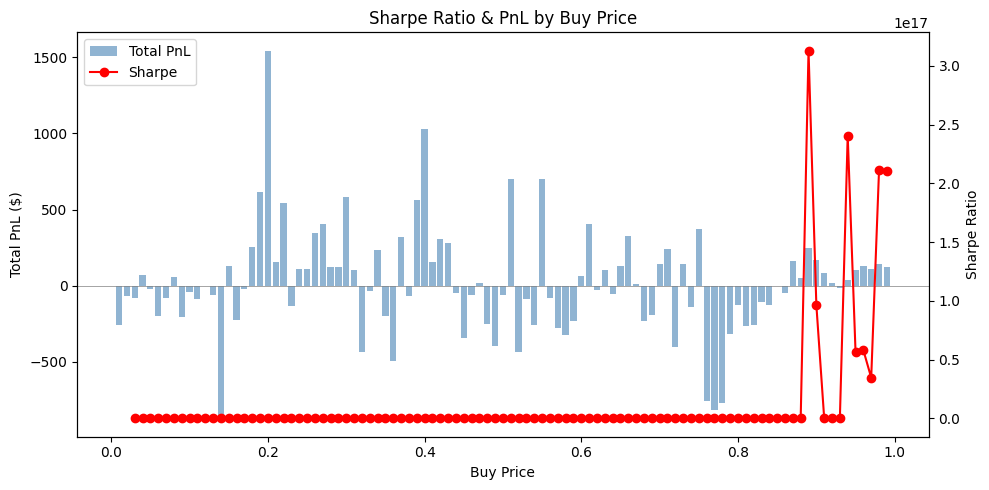

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Per-fill return: PnL per unit filled

buy_df = wallet_all[wallet_all['order_side'] == 'BUY'].copy()
buy_df['ret'] = buy_df['implied_pnl'] / (buy_df['fill_quantity'] * buy_df['order_price'])

# Sharpe per buy price
results = []
for price, grp in buy_df.groupby('order_price'):
    d = grp['ret']
    total_pnl = grp['implied_pnl'].sum()
    n = len(grp)
    win_rate = (d > 0).sum() / n
    mean_ret = d.mean()
    std_ret = d.std()
    sharpe = mean_ret / std_ret * np.sqrt(365) if std_ret > 0 else np.nan
    results.append({
        'order_price': price, 'n_fills': n, 'win_rate': win_rate,
        'mean_ret': mean_ret, 'std_ret': std_ret, 'total_pnl': total_pnl, 'sharpe': sharpe,
    })
result = pd.DataFrame(results).sort_values('order_price')
display(result)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(result['order_price'], result['total_pnl'], width=0.008, alpha=0.6, color='steelblue', label='Total PnL')
ax1.set_xlabel('Buy Price')
ax1.set_ylabel('Total PnL ($)')
ax1.axhline(0, color='grey', linewidth=0.5)

ax2 = ax1.twinx()
ax2.plot(result['order_price'], result['sharpe'], 'ro-', markersize=6, label='Sharpe')
ax2.set_ylabel('Sharpe Ratio')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title('Sharpe Ratio & PnL by Buy Price')
plt.tight_layout()
plt.show()

,delay_bucket,n_fills,win_rate,mean_ret,std_ret,total_pnl,sharpe
0,0-5s,1650,0.495152,0.112975,2.282173,-1577.690816,0.945755
1,5-10s,832,0.460337,0.081309,1.827542,1923.225470,0.850002
2,10-20s,934,0.503212,0.208348,2.487605,-999.395202,1.600126
3,20-30s,638,0.498433,0.013466,1.827535,801.049639,0.140774
4,30-45s,806,0.478908,0.197090,2.373886,1085.918787,1.586173
5,45s-1m,577,0.447140,-0.035010,1.455102,-107.233616,-0.459670
6,1-2m,1751,0.440891,-0.005026,2.071722,-1054.873506,-0.046345
7,2-3m,1183,0.445478,0.157740,2.617469,-210.470676,1.151348
8,3-5m,1995,0.446617,0.110740,2.507790,1932.456649,0.843644


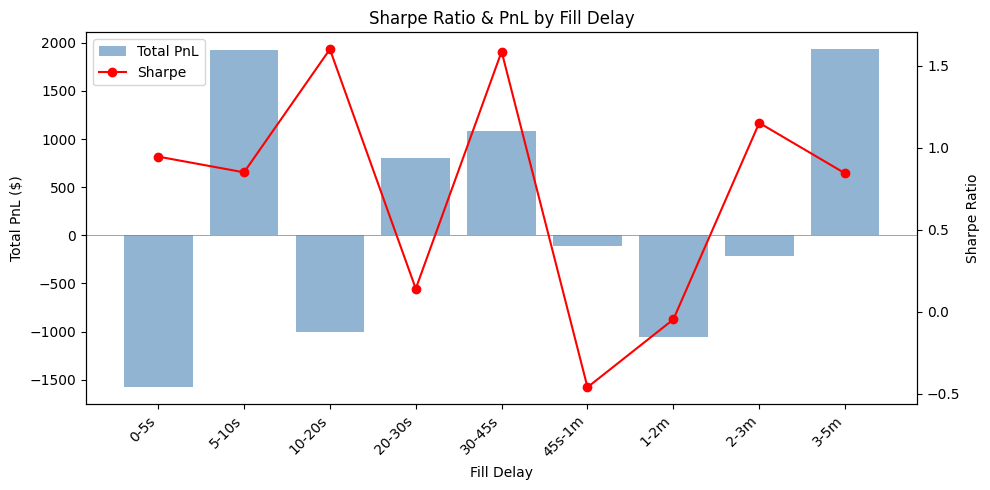

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Sharpe & PnL by fill delay (exponential buckets)

buy_df = wallet_all[wallet_all['order_side'] == 'BUY'].copy()
buy_df['ret'] = buy_df['implied_pnl'] / (buy_df['fill_quantity'] * buy_df['order_price'])

bucket_edges = [0, 5, 10, 20, 30, 45, 60, 120, 180, 300, 420, 600, 900, 1800, 3600, 10800, 86400, float('inf')]
bucket_labels = ['0-5s', '5-10s', '10-20s', '20-30s', '30-45s', '45s-1m',
                 '1-2m', '2-3m', '3-5m', '5-7m', '7-10m', '10-15m',
                 '15-30m', '30m-1h', '1-3h', '3-24h', '24h+']

buy_df['delay_bucket'] = pd.cut(buy_df['delay_s'], bins=bucket_edges, labels=bucket_labels, right=False)

results = []
for bucket, grp in buy_df.groupby('delay_bucket', observed=True):
    d = grp['ret']
    total_pnl = grp['implied_pnl'].sum()
    n = len(grp)
    win_rate = (d > 0).sum() / n
    mean_ret = d.mean()
    std_ret = d.std()
    sharpe = mean_ret / std_ret * np.sqrt(365) if std_ret > 0 else np.nan
    results.append({
        'delay_bucket': bucket, 'n_fills': n, 'win_rate': win_rate,
        'mean_ret': mean_ret, 'std_ret': std_ret, 'total_pnl': total_pnl, 'sharpe': sharpe,
    })
result = pd.DataFrame(results)
display(result)

fig, ax1 = plt.subplots(figsize=(10, 5))

x = range(len(result))
ax1.bar(x, result['total_pnl'], alpha=0.6, color='steelblue', label='Total PnL')
ax1.set_xlabel('Fill Delay')
ax1.set_ylabel('Total PnL ($)')
ax1.set_xticks(list(x))
ax1.set_xticklabels(result['delay_bucket'], rotation=45, ha='right')
ax1.axhline(0, color='grey', linewidth=0.5)

ax2 = ax1.twinx()
ax2.plot(list(x), result['sharpe'], 'ro-', markersize=6, label='Sharpe')
ax2.set_ylabel('Sharpe Ratio')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title('Sharpe Ratio & PnL by Fill Delay')
plt.tight_layout()
plt.show()